In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/avtnshm/ssl-master-dataset/ssl_master_dataset (2).csv")

# Global style
palette = {
    "BYOL": "#e74c3c",
    "SimCLR": "#2ecc71",
    "SimCLR+Jac": "#f39c12"
}

method_order = ["BYOL", "SimCLR", "SimCLR+Jac"]

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 120
})

sns.set_style("whitegrid")

# Sanity check
print("Core:", len(df[df["Experiment"]=="Core"]))
print("Tau:", len(df[df["Experiment"]=="Tau"]))
print("Transfer:", len(df[df["Experiment"].str.contains("Transfer")]))

Core: 30
Tau: 30
Transfer: 30


### Experimental Data Tables

In [2]:
df_core = df[df["Experiment"] == "Core"]

core_stats = df_core.groupby("Method").agg({
    "Jacobian": ["mean","std"],
    "Aug_Sensitivity": ["mean","std"],
    "Noise_Sensitivity": ["mean","std"],
    "Accuracy": ["mean","std"]
}).round(4)

core_stats.columns = ['_'.join(c) for c in core_stats.columns]

display(core_stats)

print(core_stats.to_latex())

,Jacobian_mean,Jacobian_std,Aug_Sensitivity_mean,Aug_Sensitivity_std,Noise_Sensitivity_mean,Noise_Sensitivity_std,Accuracy_mean,Accuracy_std
Method,,,,,,,,
BYOL,62.3177,3.7565,12.7610,0.5148,13.2679,0.9387,0.6533,0.0053
SimCLR,87.5213,1.7925,15.6302,0.3186,18.6500,0.7093,0.6947,0.0052
SimCLR+Jac,65.9729,0.9898,15.5393,0.6224,16.0637,0.3935,0.6751,0.0034


\begin{tabular}{lrrrrrrrr}
\toprule
 & Jacobian_mean & Jacobian_std & Aug_Sensitivity_mean & Aug_Sensitivity_std & Noise_Sensitivity_mean & Noise_Sensitivity_std & Accuracy_mean & Accuracy_std \\
Method &  &  &  &  &  &  &  &  \\
\midrule
BYOL & 62.317700 & 3.756500 & 12.761000 & 0.514800 & 13.267900 & 0.938700 & 0.653300 & 0.005300 \\
SimCLR & 87.521300 & 1.792500 & 15.630200 & 0.318600 & 18.650000 & 0.709300 & 0.694700 & 0.005200 \\
SimCLR+Jac & 65.972900 & 0.989800 & 15.539300 & 0.622400 & 16.063700 & 0.393500 & 0.675100 & 0.003400 \\
\bottomrule
\end{tabular}



In [3]:
df_tau = df[df["Experiment"] == "Tau"]

tau_stats = df_tau.groupby("Tau").agg({
    "Jacobian": ["mean","std"],
    "Noise_Sensitivity": ["mean","std"]
}).round(4)

tau_stats.columns = ['_'.join(c) for c in tau_stats.columns]

display(tau_stats)
print(tau_stats.to_latex())

,Jacobian_mean,Jacobian_std,Noise_Sensitivity_mean,Noise_Sensitivity_std
Tau,,,,
0.1,104.8962,1.3415,19.6332,0.6250
0.5,88.7575,1.4338,19.0864,0.5394
1.0,77.6758,1.7367,18.1770,0.9179


\begin{tabular}{lrrrr}
\toprule
 & Jacobian_mean & Jacobian_std & Noise_Sensitivity_mean & Noise_Sensitivity_std \\
Tau &  &  &  &  \\
\midrule
0.100000 & 104.896200 & 1.341500 & 19.633200 & 0.625000 \\
0.500000 & 88.757500 & 1.433800 & 19.086400 & 0.539400 \\
1.000000 & 77.675800 & 1.736700 & 18.177000 & 0.917900 \\
\bottomrule
\end{tabular}



### Plots

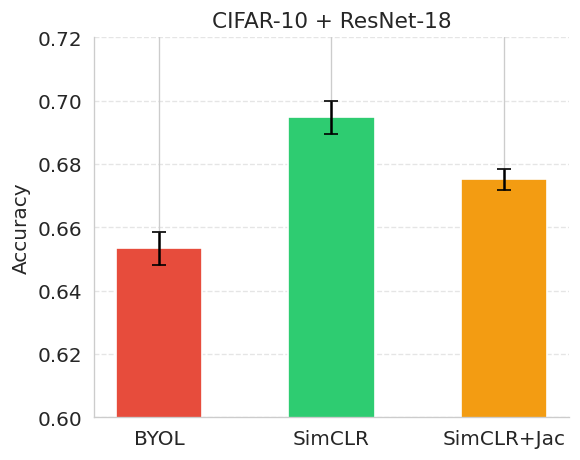

In [4]:
stats = df_core.groupby("Method")["Accuracy"].agg(["mean","std"]).reset_index()
stats = stats.set_index("Method").loc[method_order].reset_index()

plt.figure(figsize=(5,4))

plt.bar(
    stats["Method"],
    stats["mean"],
    yerr=stats["std"],
    capsize=4,
    width=0.5,
    color=[palette[m] for m in stats["Method"]]
)

plt.ylabel("Accuracy")
plt.title("CIFAR-10 + ResNet-18")
plt.ylim(0.60, 0.72)

plt.grid(axis="y", linestyle="--", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.savefig("fig1_core_accuracy.pdf", dpi=300, bbox_inches="tight")
plt.savefig("fig1_core_accuracy.png", dpi=300)
plt.show()

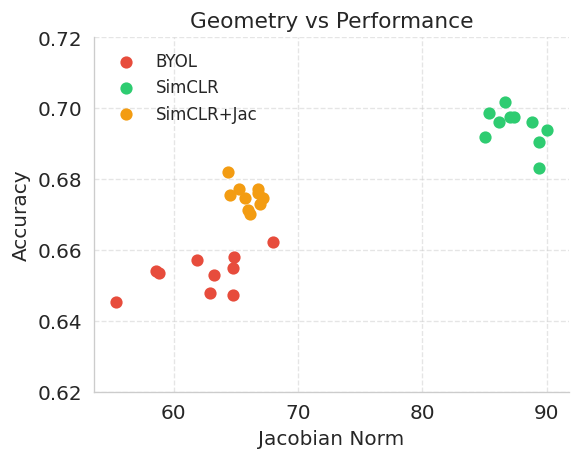

In [5]:
plt.figure(figsize=(5,4))

for method in method_order:
    d = df_core[df_core["Method"] == method]
    plt.scatter(d["Jacobian"], d["Accuracy"], label=method, s=40, color=palette[method])

plt.xlabel("Jacobian Norm")
plt.ylabel("Accuracy")
plt.title("Geometry vs Performance")
plt.ylim(0.62, 0.72)

plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.savefig("fig2_geometry.pdf", dpi=300, bbox_inches="tight")
plt.savefig("fig2_geometry.png", dpi=300)
plt.show()

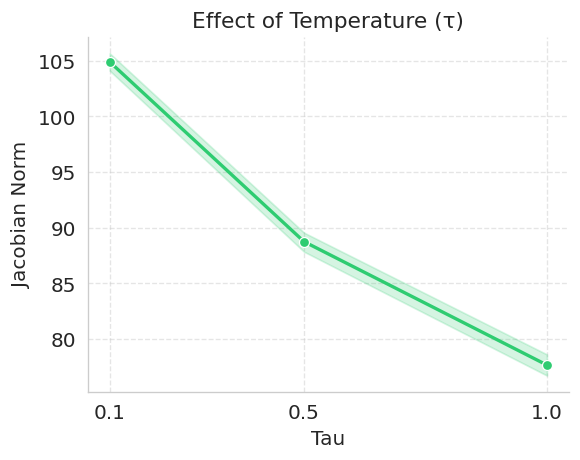

In [6]:
plt.figure(figsize=(5,4))

sns.lineplot(
    data=df_tau,
    x="Tau",
    y="Jacobian",
    marker="o",
    linewidth=2,
    color=palette["SimCLR"]
)

plt.title("Effect of Temperature (τ)")
plt.ylabel("Jacobian Norm")
plt.xticks([0.1, 0.5, 1.0])

plt.grid(True, linestyle="--", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.savefig("fig3_tau_jacobian.pdf", dpi=300, bbox_inches="tight")
plt.savefig("fig3_tau_jacobian.png", dpi=300)
plt.show()

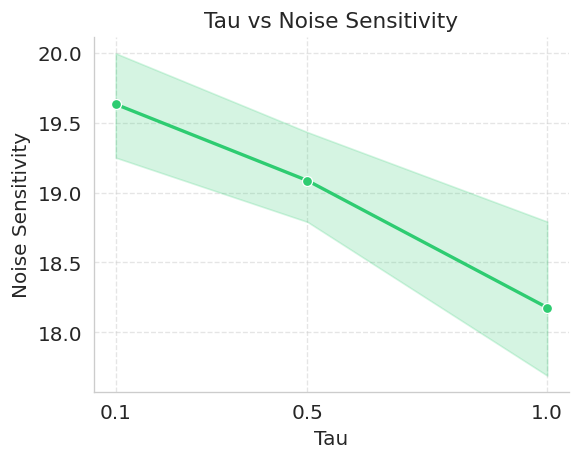

In [7]:
plt.figure(figsize=(5,4))

sns.lineplot(
    data=df_tau,
    x="Tau",
    y="Noise_Sensitivity",
    marker="o",
    linewidth=2,
    color=palette["SimCLR"]
)

plt.title("Tau vs Noise Sensitivity")
plt.ylabel("Noise Sensitivity")
plt.xticks([0.1, 0.5, 1.0])

plt.grid(True, linestyle="--", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.savefig("fig4_tau_noise.pdf", dpi=300, bbox_inches="tight")
plt.savefig("fig4_tau_noise.png", dpi=300)
plt.show()

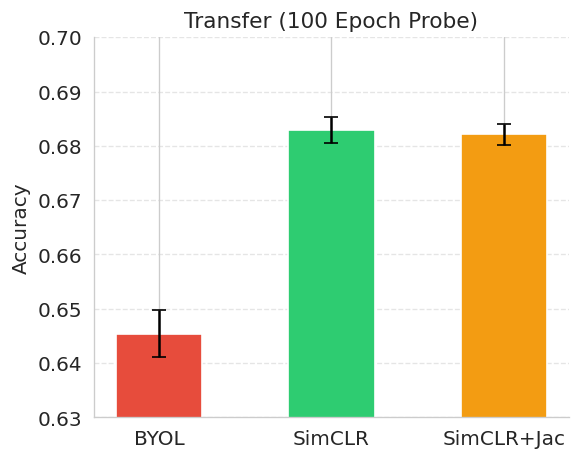

\begin{tabular}{lrr}
\toprule
Method & mean & std \\
\midrule
BYOL & 0.645400 & 0.004317 \\
SimCLR & 0.682880 & 0.002408 \\
SimCLR+Jac & 0.682120 & 0.001964 \\
\bottomrule
\end{tabular}



In [8]:
df_t100 = df[df["Experiment"] == "Transfer_100E"]

stats = df_t100.groupby("Method")["Accuracy"].agg(["mean","std"]).reset_index()

methods = stats["Method"].tolist()

plt.figure(figsize=(5,4))

plt.bar(
    stats["Method"],
    stats["mean"],
    yerr=stats["std"],
    capsize=4,
    width=0.5,
    color=[palette[m] for m in methods]
)

plt.ylabel("Accuracy")
plt.title("Transfer (100 Epoch Probe)")
plt.ylim(0.63, 0.70)

plt.grid(axis="y", linestyle="--", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.savefig("fig5_transfer100.pdf", dpi=300, bbox_inches="tight")
plt.savefig("fig5_transfer100.png", dpi=300)
plt.show()

print(stats.to_latex(index=False))

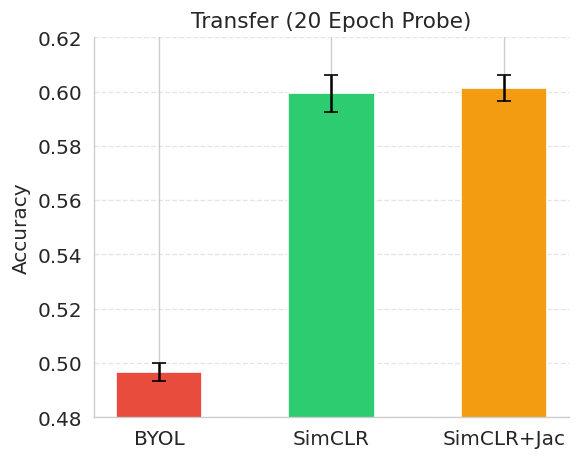

\begin{tabular}{lrr}
\toprule
Method & mean & std \\
\midrule
BYOL & 0.496700 & 0.003470 \\
SimCLR & 0.599340 & 0.006743 \\
SimCLR+Jac & 0.601260 & 0.004675 \\
\bottomrule
\end{tabular}



In [9]:
df_t20 = df[df["Experiment"] == "Transfer_20E"]

stats = df_t20.groupby("Method")["Accuracy"].agg(["mean","std"]).reset_index()

plt.figure(figsize=(5,4))

plt.bar(
    stats["Method"],
    stats["mean"],
    yerr=stats["std"],
    capsize=4,
    width=0.5,
    color=[palette[m] for m in stats["Method"]]
)

plt.ylabel("Accuracy")
plt.title("Transfer (20 Epoch Probe)")
plt.ylim(0.48, 0.62)

plt.grid(axis="y", linestyle="--", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.savefig("fig6_transfer20.pdf", dpi=300, bbox_inches="tight")
plt.savefig("fig6_transfer20.png", dpi=300)
plt.show()

print(stats.to_latex(index=False))

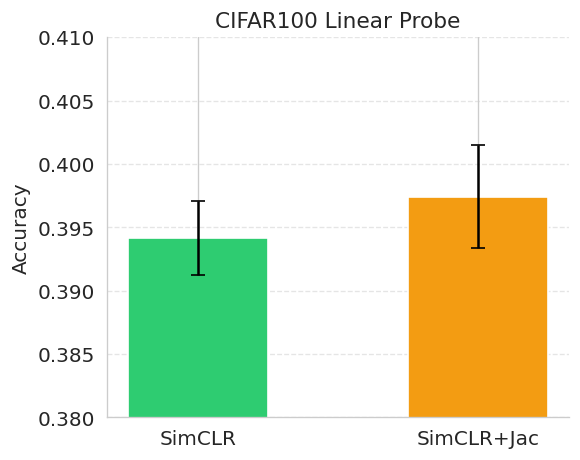

\begin{tabular}{lrr}
\toprule
Method & mean & std \\
\midrule
SimCLR & 0.394140 & 0.002938 \\
SimCLR+Jac & 0.397400 & 0.004068 \\
\bottomrule
\end{tabular}



In [10]:
df_probe = df[df["Experiment"] == "Probe_CIFAR100"]

stats = df_probe.groupby("Method")["Accuracy"].agg(["mean","std"]).reset_index()

plt.figure(figsize=(5,4))

plt.bar(
    stats["Method"],
    stats["mean"],
    yerr=stats["std"],
    capsize=4,
    width=0.5,
    color=[palette[m] for m in stats["Method"]]
)

plt.ylabel("Accuracy")
plt.title("CIFAR100 Linear Probe")
plt.ylim(0.38, 0.41)

plt.grid(axis="y", linestyle="--", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.savefig("fig7_cifar100.pdf", dpi=300, bbox_inches="tight")
plt.savefig("fig7_cifar100.png", dpi=300)
plt.show()

print(stats.to_latex(index=False))

In [11]:
def paired_test(df, metric, m1, m2):
    d1 = df[df["Method"] == m1][metric].values
    d2 = df[df["Method"] == m2][metric].values
    t, p = ttest_rel(d1, d2)
    print(f"{m1} vs {m2} ({metric}) → t={t:.4f}, p={p:.6f}")

print("CORE TESTS")
paired_test(df_core, "Accuracy", "SimCLR", "SimCLR+Jac")
paired_test(df_core, "Jacobian", "SimCLR", "SimCLR+Jac")
paired_test(df_core, "Noise_Sensitivity", "SimCLR", "SimCLR+Jac")

print("\nTRANSFER 100E")
paired_test(df_t100, "Accuracy", "SimCLR", "SimCLR+Jac")

print("\nTRANSFER 20E")
paired_test(df_t20, "Accuracy", "SimCLR", "SimCLR+Jac")

print("\nCIFAR100 PROBE")
paired_test(df_probe, "Accuracy", "SimCLR", "SimCLR+Jac")

CORE TESTS
SimCLR vs SimCLR+Jac (Accuracy) → t=9.8698, p=0.000004
SimCLR vs SimCLR+Jac (Jacobian) → t=36.5335, p=0.000000
SimCLR vs SimCLR+Jac (Noise_Sensitivity) → t=10.0480, p=0.000003

TRANSFER 100E
SimCLR vs SimCLR+Jac (Accuracy) → t=0.4458, p=0.678821

TRANSFER 20E
SimCLR vs SimCLR+Jac (Accuracy) → t=-0.4981, p=0.644567

CIFAR100 PROBE
SimCLR vs SimCLR+Jac (Accuracy) → t=-2.3077, p=0.082239


In [12]:
# NOTE:
# This cell depends on:
# df_core, df_t100, df_t20, df_probe
# Ensure previous cells defining these are executed.

import numpy as np
from scipy.stats import ttest_rel

def paired_test(df, metric, m1, m2, name):
    d1 = df[df["Method"] == m1][metric].values
    d2 = df[df["Method"] == m2][metric].values

    # --- Safety: method existence ---
    if len(d1) == 0 or len(d2) == 0:
        print(f"{name} | {metric}: SKIPPED ({m1} or {m2} missing)")
        return

    # --- Critical: length check ---
    assert len(d1) == len(d2), f"Length mismatch: {len(d1)} vs {len(d2)} for {metric}"

    # --- t-test ---
    t, p = ttest_rel(d1, d2)

    # --- Effect size (Cohen's d for paired samples) ---
    diff = d2 - d1
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)
    d = mean_diff / std_diff if std_diff != 0 else 0.0

    # --- significance ---
    sig = "SIGNIFICANT" if p < 0.05 else "NOT SIGNIFICANT"

    print(f"{name} | {m1} vs {m2} ({metric})")
    print(f"  t = {t:.4f}, p = {p:.6f}, d = {d:.4f} [{sig}]")
    print(f"  Mean diff ({m2}-{m1}) = {mean_diff:.4f}")
    print("-"*60)


print("======== CORE EXPERIMENT ========")

paired_test(df_core, "Accuracy", "SimCLR", "SimCLR+Jac", "Core")
paired_test(df_core, "Jacobian", "SimCLR", "SimCLR+Jac", "Core")
paired_test(df_core, "Noise_Sensitivity", "SimCLR", "SimCLR+Jac", "Core")

# Additional baseline comparisons (important)
paired_test(df_core, "Accuracy", "BYOL", "SimCLR", "Core")
paired_test(df_core, "Jacobian", "BYOL", "SimCLR", "Core")


print("\n======== TRANSFER 100E ========")

paired_test(df_t100, "Accuracy", "SimCLR", "SimCLR+Jac", "Transfer100")


print("\n======== TRANSFER 20E ========")

paired_test(df_t20, "Accuracy", "SimCLR", "SimCLR+Jac", "Transfer20")


print("\n======== CIFAR100 PROBE ========")

paired_test(df_probe, "Accuracy", "SimCLR", "SimCLR+Jac", "CIFAR100")

======== CORE EXPERIMENT ========
Core | SimCLR vs SimCLR+Jac (Accuracy)
  t = 9.8698, p = 0.000004, d = -3.1211 [SIGNIFICANT]
  Mean diff (SimCLR+Jac-SimCLR) = -0.0196
------------------------------------------------------------
Core | SimCLR vs SimCLR+Jac (Jacobian)
  t = 36.5335, p = 0.000000, d = -11.5529 [SIGNIFICANT]
  Mean diff (SimCLR+Jac-SimCLR) = -21.5484
------------------------------------------------------------
Core | SimCLR vs SimCLR+Jac (Noise_Sensitivity)
  t = 10.0480, p = 0.000003, d = -3.1775 [SIGNIFICANT]
  Mean diff (SimCLR+Jac-SimCLR) = -2.5863
------------------------------------------------------------
Core | BYOL vs SimCLR (Accuracy)
  t = -18.4925, p = 0.000000, d = 5.8478 [SIGNIFICANT]
  Mean diff (SimCLR-BYOL) = 0.0414
------------------------------------------------------------
Core | BYOL vs SimCLR (Jacobian)
  t = -23.7341, p = 0.000000, d = 7.5054 [SIGNIFICANT]
  Mean diff (SimCLR-BYOL) = 25.2035
---------------------------------------------------------